# Langkah 1
## Pengerjaan Model Utama

* ### Library 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

* ### Load Dataset

In [12]:
df=pd.read_csv('ai4i2020.csv')
display(df.head())
print("info data set :")
df.info()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


info data set :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: floa

### TWF (Tool Wear Failure)
### HDF (Heat Dissipation Failure)
### PWF (Power Failure)
### OSF (Overstrain Failure)
### RNF (Random Failure)

# Langkah 2
## Data Preprocessing

In [13]:
# UDI & Product ID tidak memengaruhi kerusakan mesin
df_clean=df.drop(['UDI','Product ID'], axis=1)

* ### Enkoding Data (kategorikal)

In [14]:
# contoh L=0 M=1 H=2
le=LabelEncoder()
df_clean['Type']=le.fit_transform(df_clean['Type'])

* ### Menentukan x dan y

In [ ]:
x=df_clean.drop(['Machine failure','TWF','HDF','PWF','OSF','RNF'], axis=1)
# memprediksi 'apakah akan rusak' hanya berdasarkan sensor suhu/tors
y=df_clean['Machine failure']

* ### Split Data(80% train , 20% test)

In [25]:
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print(f"jumlah train {x_train.shape[0]}")
print(f"jumlah test {x_test.shape[0]}")

jumlah train 8000
jumlah test 2000


# Langkah 3
## training

In [26]:
rf_model=RandomForestClassifier(n_estimators=100,random_state=42)
rf_model.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# Langkah 4
## Evaluasi

In [27]:
y_pred=rf_model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1939
           1       0.84      0.59      0.69        61

    accuracy                           0.98      2000
   macro avg       0.91      0.79      0.84      2000
weighted avg       0.98      0.98      0.98      2000



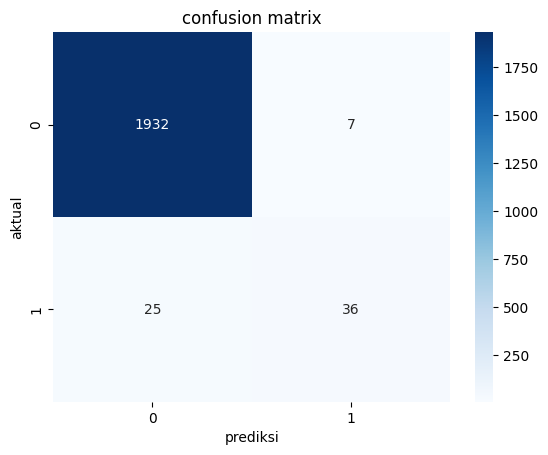

In [30]:
conf_matrix = confusion_matrix(y_test,y_pred)
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d')
plt.title('confusion matrix')
plt.xlabel('prediksi')
plt.ylabel('aktual')
plt.show()

# Langkah 5
## Optimalisasi Model

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=3, scoring='f1', n_jobs=-1)
grid_search.fit(x_train, y_train)

print(f"Parameter Terbaik: {grid_search.best_params_}")

best_model = grid_search.best_estimator_

Parameter Terbaik: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}


# Langkah 6
## Save Model

In [35]:
import joblib

joblib.dump(best_model, 'smartguard_model.pkl')
print("Model berhasil disimpan sebagai 'smartguard_model.pkl'")

Model berhasil disimpan sebagai 'smartguard_model.pkl'
